In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


#(warning)
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('healthcare-dataset-stroke-data.csv')
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [6]:
import pandas as pd

# نفترض ان df هو اسم DataFrame
print(df['bmi'].describe())


count    4909.000000
mean       28.893237
std         7.854067
min        10.300000
25%        23.500000
50%        28.100000
75%        33.100000
max        97.600000
Name: bmi, dtype: float64


In [7]:
df['bmi'].fillna(df['bmi'].median(), inplace=True)


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [9]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.862035,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.699562,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.800000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,32.800000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


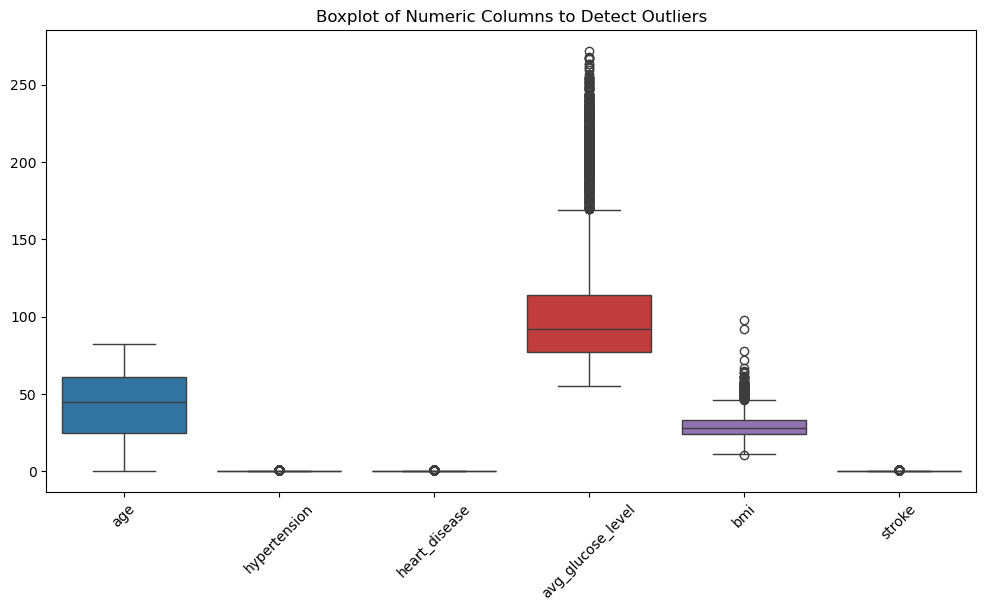

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# الأعمدة الرقمية فقط
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

plt.figure(figsize=(12,6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplot of Numeric Columns to Detect Outliers')
plt.xticks(rotation=45)
plt.show()


In [11]:
def detect_outliers_IQR(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    return outliers


for col in numeric_cols:
    outliers = detect_outliers_IQR(df, col)
    print(f"{col}: {len(outliers)} outliers detected")

age: 0 outliers detected
hypertension: 498 outliers detected
heart_disease: 276 outliers detected
avg_glucose_level: 627 outliers detected
bmi: 126 outliers detected
stroke: 249 outliers detected


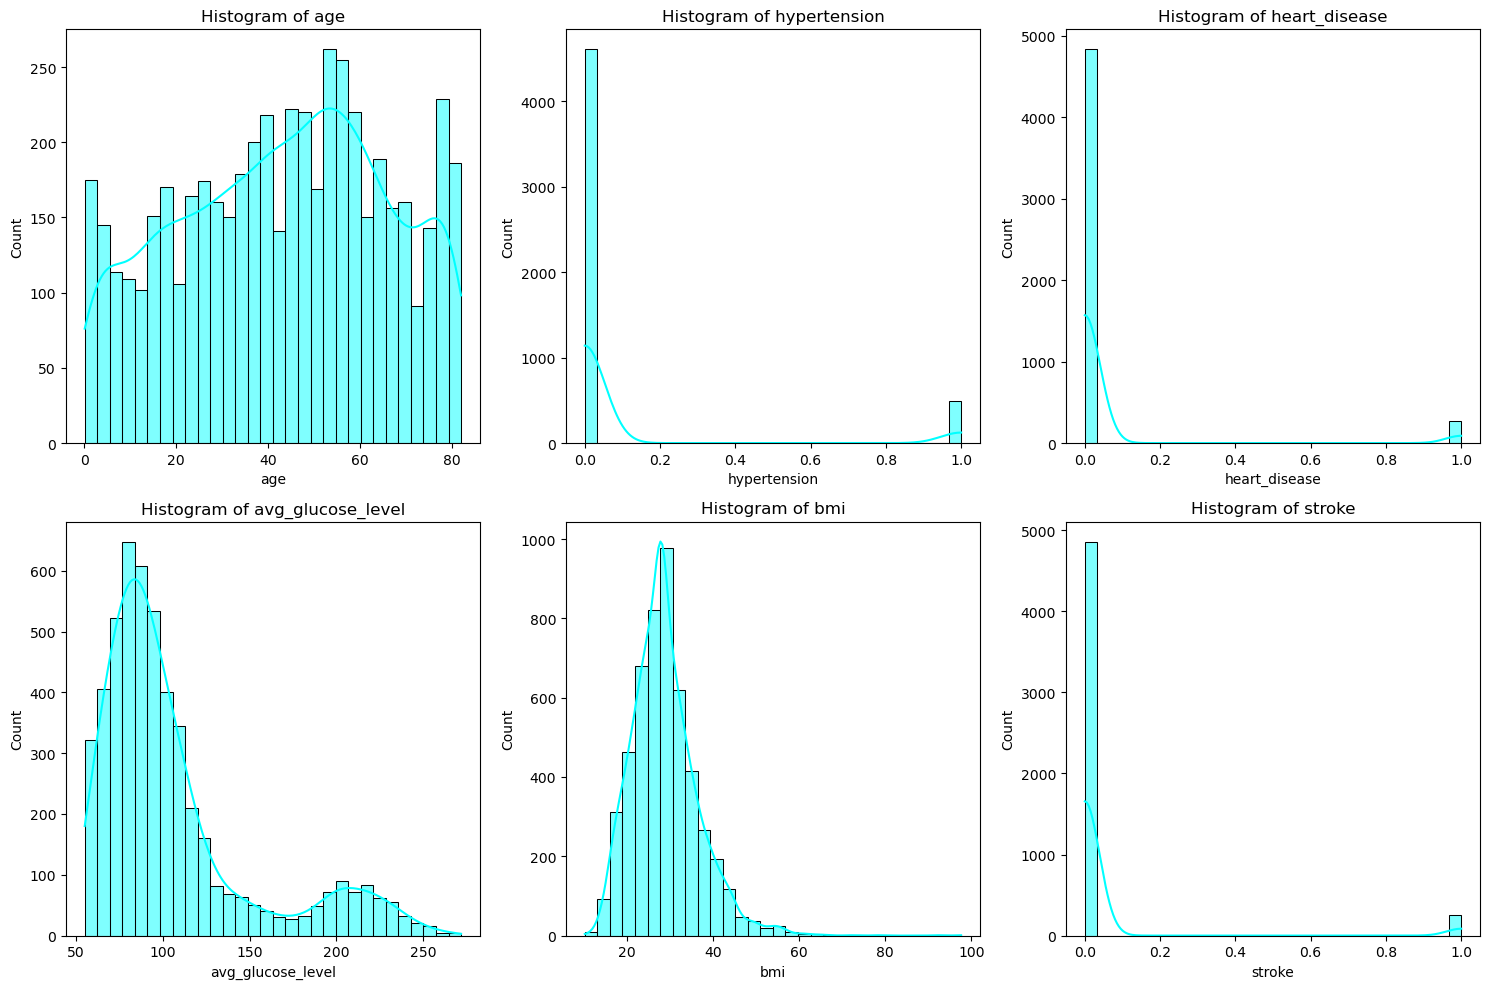

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='cyan')  # ممكن تغيري اللون هنا مباشرة
    plt.title(f'Histogram of {col}')  # بدون fg_color
plt.tight_layout()
plt.show()


In [13]:
df['avg_glucose_level'] = np.log1p(df['avg_glucose_level'])
df['bmi'] = np.log1p(df['bmi'])


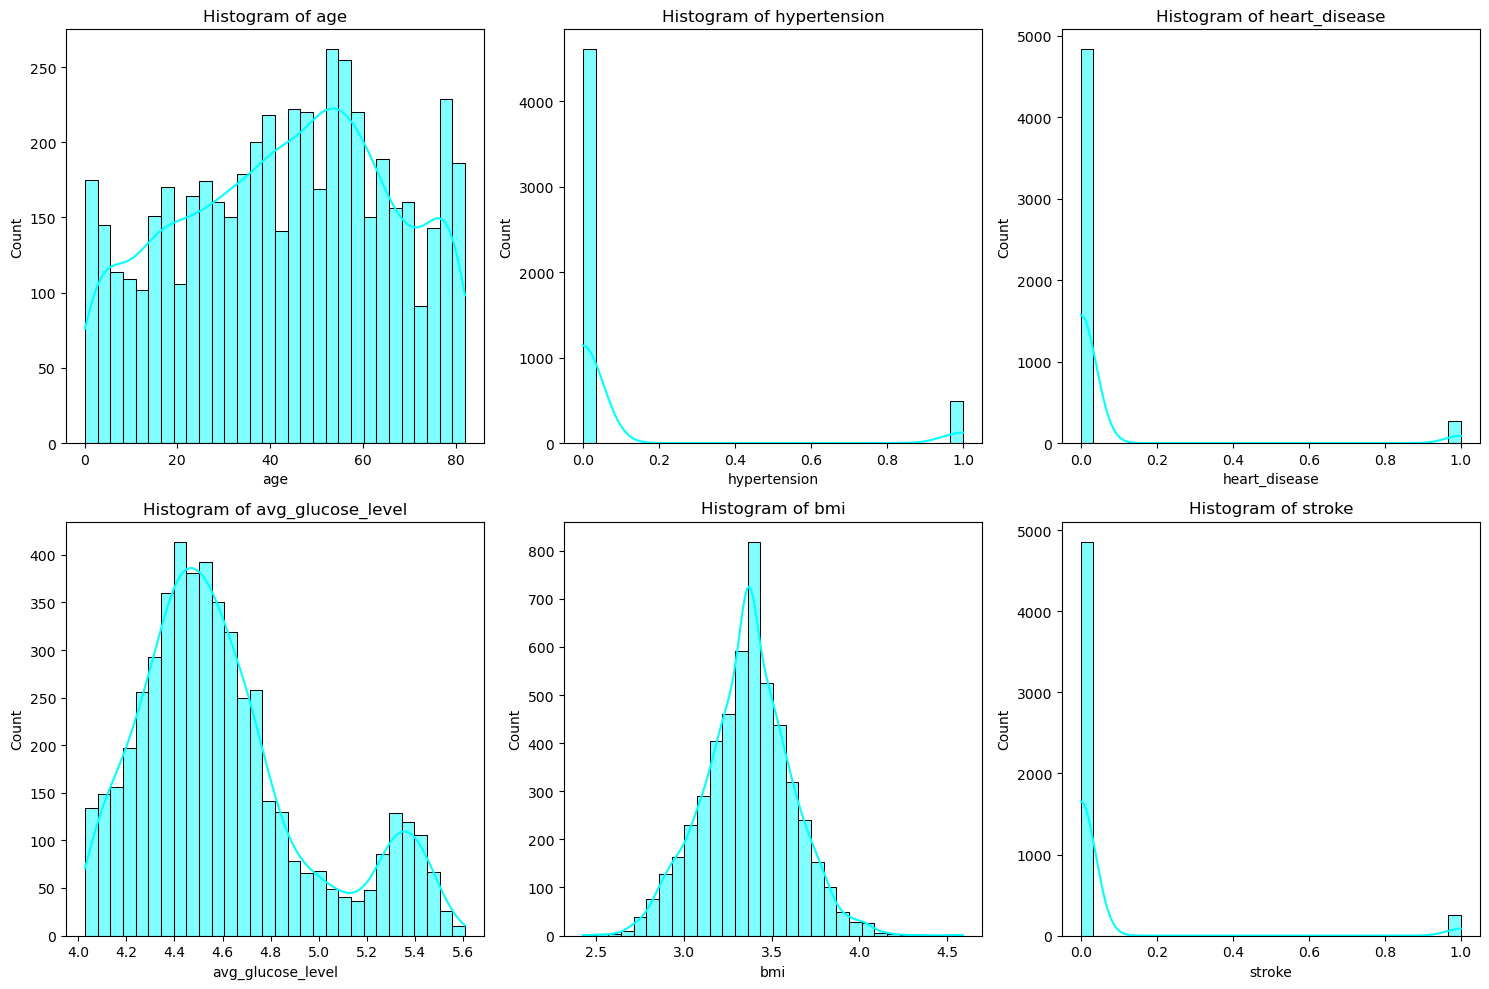

In [14]:
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

plt.figure(figsize=(15,10))

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 3, i)
    sns.histplot(df[col], bins=30, kde=True, color='cyan')  # ممكن تغيري اللون هنا مباشرة
    plt.title(f'Histogram of {col}')  # بدون fg_color
plt.tight_layout()
plt.show()


In [15]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                5110 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [16]:
df[(df['bmi'] < 10) | (df['bmi'] > 80)]


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,5.436731,3.627004,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,5.314240,3.370738,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,4.672081,3.511545,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,5.148831,3.566712,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,5.165471,3.218876,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,4.439706,3.370738,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,4.837868,3.713572,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,4.430698,3.453157,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,5.119729,3.280911,formerly smoked,0


In [17]:
df.drop(columns=['id'], inplace=True)


In [18]:
df['gender'].value_counts()


gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64

In [19]:
df = df[df['gender'] != 'Other']


In [20]:
df['gender'].value_counts()


gender
Female    2994
Male      2115
Name: count, dtype: int64

In [21]:
df['work_type'].value_counts()


work_type
Private          2924
Self-employed     819
children          687
Govt_job          657
Never_worked       22
Name: count, dtype: int64

In [22]:
#نحوّل Never_worked → children
df['work_type'] = df['work_type'].replace('Never_worked', 'children')


In [23]:
df['work_type'].value_counts()


work_type
Private          2924
Self-employed     819
children          709
Govt_job          657
Name: count, dtype: int64

In [24]:
df['smoking_status'].value_counts(normalize=True) * 100


smoking_status
never smoked       37.032687
Unknown            30.221178
formerly smoked    17.302799
smokes             15.443335
Name: proportion, dtype: float64

#Unknown ≈ 30%

🥇 خليه Category مستقلة

لأن:

نسبته كبيرة

ممكن يكون له دلالة (ناس ما صرحتش)

الموديل يتعامل معاه كويس في One-Hot

✔️ سيبيه زي ما هو

In [25]:
cat_cols = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

from sklearn.preprocessing import OneHotEncoder
import sklearn

if sklearn.__version__ >= '1.2':
    encoder = OneHotEncoder(drop='first', sparse_output=False)
else:
    encoder = OneHotEncoder(drop='first', sparse=False)

encoded = encoder.fit_transform(df[cat_cols])


In [26]:
df['stroke'].value_counts(normalize=True) * 100


stroke
0    95.126248
1     4.873752
Name: proportion, dtype: float64

In [27]:
# 3. Categorical unique values
cat_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']
for col in cat_cols:
    print(col, df[col].unique())

gender ['Male' 'Female']
ever_married ['Yes' 'No']
work_type ['Private' 'Self-employed' 'Govt_job' 'children']
Residence_type ['Urban' 'Rural']
smoking_status ['formerly smoked' 'never smoked' 'smokes' 'Unknown']


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = ['age', 'avg_glucose_level', 'bmi']
cat_cols = ['gender','ever_married','work_type','Residence_type','smoking_status']

preprocess = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
])


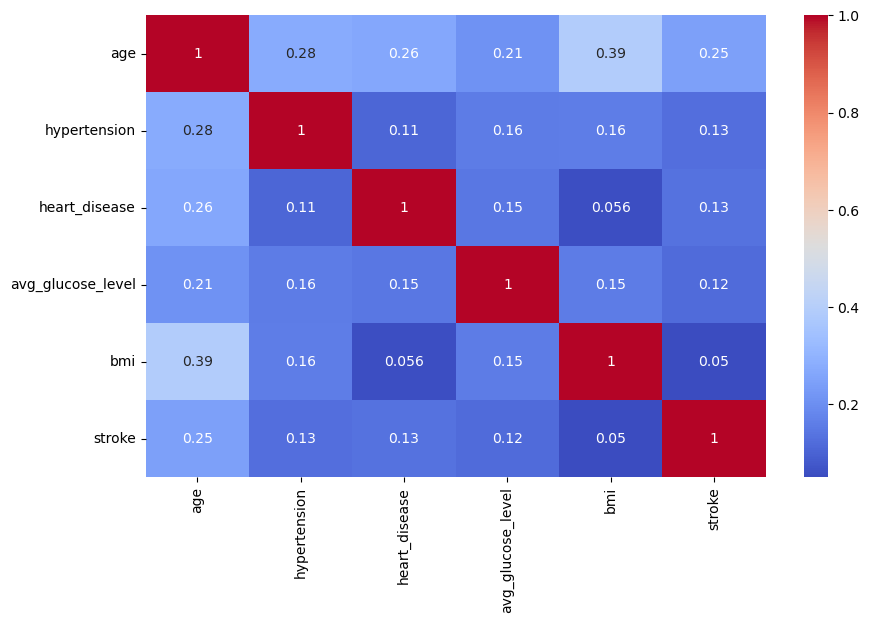

In [29]:
num_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()



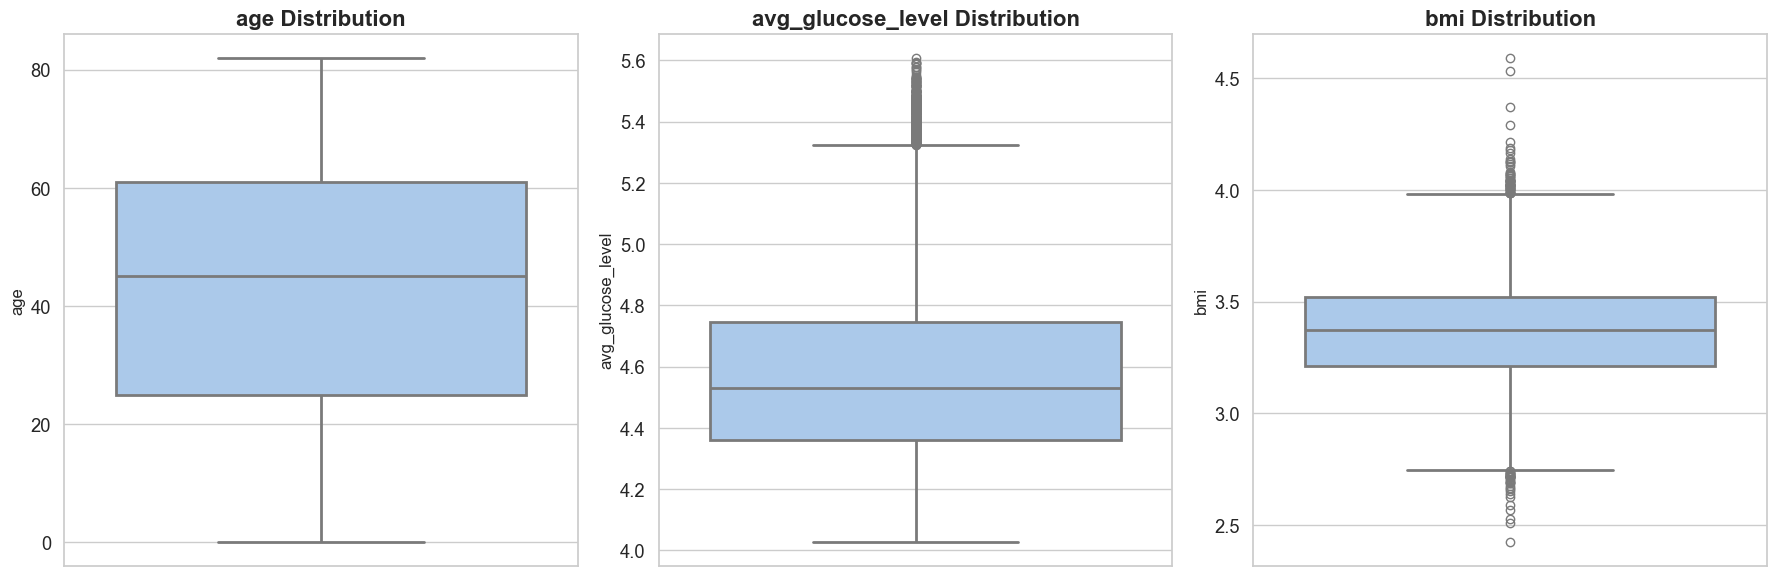

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ستايل حديث وألوان جذابة
sns.set(style="whitegrid", palette="Set2", font_scale=1.2)

numeric_cols = ['age', 'avg_glucose_level', 'bmi']

plt.figure(figsize=(18,6))

for i, col in enumerate(numeric_cols):
    plt.subplot(1, len(numeric_cols), i+1)
    
    # Boxplot جذاب بدون نقاط فردية
    sns.boxplot(y=df[col], palette="pastel", linewidth=2)
    
    plt.title(f'{col} Distribution', fontsize=16, fontweight='bold')
    plt.ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()



In [31]:
numeric_cols = ['age', 'avg_glucose_level', 'bmi']

outlier_counts = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    # الشرط لتحديد الـ outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_counts[col] = len(outliers)

outlier_counts


{'age': 0, 'avg_glucose_level': 384, 'bmi': 88}

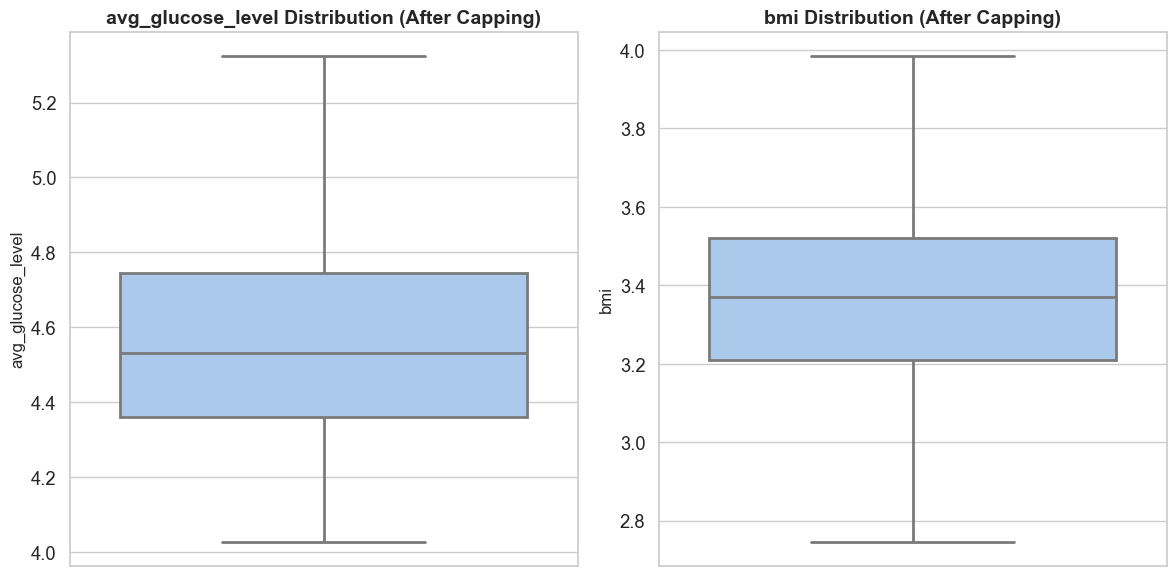

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# الأعمدة اللي عايزين نصححها
cols_to_fix = ['avg_glucose_level', 'bmi']

# Capping للـ outliers
for col in cols_to_fix:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5*IQR
    upper_bound = Q3 + 1.5*IQR
    
    # تطبيق Capping
    df[col] = df[col].apply(lambda x: lower_bound if x < lower_bound else upper_bound if x > upper_bound else x)

# رسم Box Plot حديث وجذاب بعد المعالجة
sns.set(style="whitegrid", palette="Set2", font_scale=1.2)
plt.figure(figsize=(12,6))

for i, col in enumerate(cols_to_fix):
    plt.subplot(1, len(cols_to_fix), i+1)
    sns.boxplot(y=df[col], palette="pastel", linewidth=2)
    plt.title(f'{col} Distribution (After Capping)', fontsize=14, fontweight='bold')
    plt.ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()


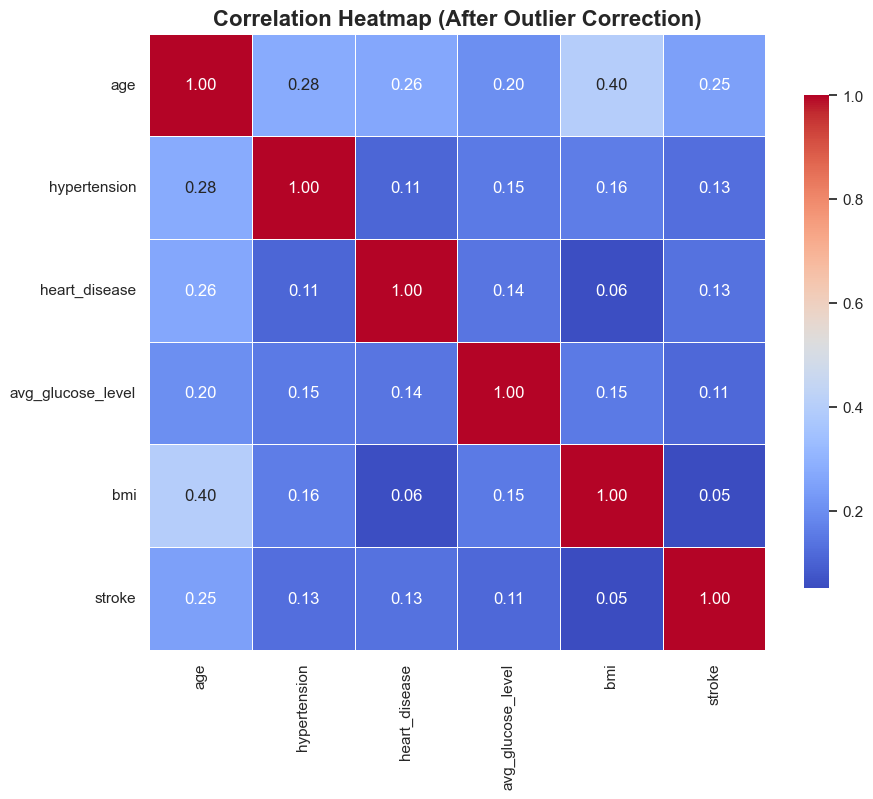

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# الأعمدة العددية اللي هنعمل لها correlation
numeric_cols = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']

# حساب correlation بعد Capping
corr = df[numeric_cols].corr()

# رسم Heatmap حديث وجذاب
plt.figure(figsize=(10,8))
sns.set(style="white")
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, square=True, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap (After Outlier Correction)', fontsize=16, fontweight='bold')
plt.show()


In [34]:
الخلاصة العملية: ترتيب الخطوات قبل Classification

Feature Selection (أو استخدام كل الأعمدة أولًا)

Encoding + Scaling

Train/Test split

التعامل مع Imbalanced Data (لو موجود)

تدريب الموديل

تقييم الأداء (Accuracy, Precision, Recall, F1-score, ROC-AUC)

Refinement: تعديل features أو hyperparameters

SyntaxError: invalid syntax (2394899193.py, line 1)

🔹 أولًا: وضع الداتا بتاعتك (عشان نبني عليه)

Classification (Target = stroke)

عدد الـ features ≈ 11 عمود

في numerical + categorical

غالبًا الداتا imbalanced

الحجم مش ضخم → ينفع نجرب أكتر من method

➡️ النتيجة:
ينفع نجرّب كل الطرق اللي في المحاضرة ونقارن بينهم ✔️
وده هيقوي المشروع جدًا.

1️⃣ Feature Selection Types – إيه اللي ينفع؟
✅ 1. Filter Methods (ينفع جدًا)

تعتمد على الإحصاء فقط، بدون موديل.

اللي ينفع عندك:

Correlation with target

سهل

سريع

كويس كبداية

Chi-Square

مناسب للـ categorical features

ANOVA (f_classif)

ممتاز للـ numerical features مع classification

✔️ ليه نستخدمهم؟

سريع

computationally efficient

يقلل عدد الـ features قبل أي موديل

❌ عيبه

مش بياخد في اعتباره تفاعل الـ features مع بعض

✅ 2. Wrapper Methods (ينفع جدًا بس بحذر)

بيعتمد على موديل ويجرب combinations.

اللي ينفع:

RFE (Recursive Feature Elimination)
مع:

Logistic Regression

Random Forest

✔️ مميزاته

أدق من filter

بيختار features بناءً على الأداء الفعلي

❌ عيوبه

أبطأ شوية

مكلف حسابيًا (بس عندك 11 عمود → تمام)

✅ 3. Embedded Methods (Regularization)

وده يربطك بنقطة L1 & L2

2️⃣ Regularization (L1 & L2) – ينفع إزاي؟
🔸 L1 Regularization (Lasso)

بيصفر weights لبعض features

يعني بيعمل feature selection تلقائي

✔️ ينفع جدًا مع:

Logistic Regression + penalty='l1'

📌 Effect:

يقلل model complexity

يشيل features الضعيفة

يحسن generalization

🔸 L2 Regularization (Ridge)

بيقلل weights لكن مش بيصفرها

مش feature selection صريح

✔️ مفيد لـ:

تقليل overfitting

تحسين الاستقرار

📌 Effect:

كل features تفضل موجودة

بس التأثير يتوزع

🔁 مقارنة سريعة:
Method	Feature Selection	Overfitting
L1	✔️ نعم	✔️ يقلله
L2	❌ لا	✔️ يقلله
3️⃣ Optimize Feature Selection (Efficiency & Generalization)

إنتِ ممكن تعملي ده بالشكل الأكاديمي الصح:

🧠 Strategy ذكية:

Filter method
→ تقللي من 11 → مثلًا 7 أو 8

Wrapper / L1
→ تختاري الأفضل فعليًا

Model Training

Comparison

ده:

يقلل وقت التدريب

يقلل overfitting

يحسن performance على test set

1️⃣ Correlation with Target (Pearson)
🔹 الفكرة (نظري – مهم للمحاضرة)

بنقيس العلاقة الخطية بين كل feature والـ target

القيم:

قريب من 1 أو -1 → feature مؤثر

قريب من 0 → تأثير ضعيف

In [35]:
# الأعمدة الرقمية فقط
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# correlation
corr = numeric_df.corr()

# correlation مع target
target_corr = corr['stroke'].sort_values(ascending=False)

target_corr



stroke               1.000000
age                  0.245239
heart_disease        0.134905
hypertension         0.127891
avg_glucose_level    0.113470
bmi                  0.051191
Name: stroke, dtype: float64

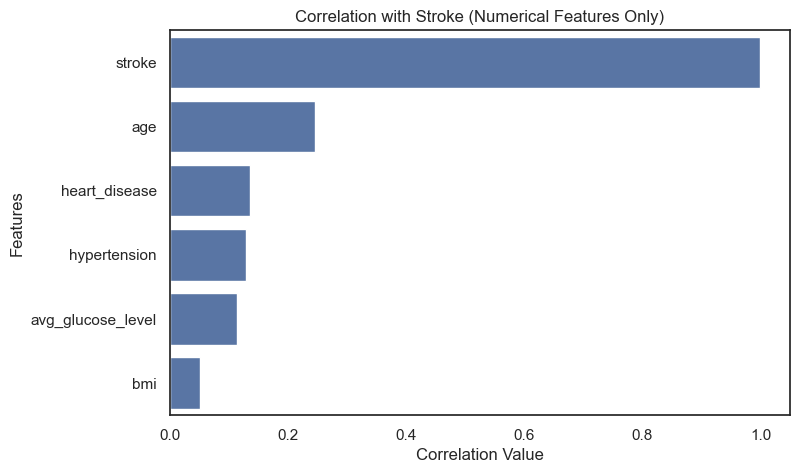

In [36]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=target_corr.values,
    y=target_corr.index
)
plt.title("Correlation with Stroke (Numerical Features Only)")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.show()


🟢 STEP 2: ANOVA (f_classif)
🎯 الهدف

نقيس قدرة كل feature رقمية على التمييز بين فئتي الـ stroke
(مصاب / غير مصاب)

🔹 الفكرة النظرية (مهمة للمحاضرة)

ANOVA تقيس الفرق بين متوسطات الـ feature في كل class.

كل ما:

ANOVA score أكبر → feature أقوى في التصنيف.

مناسبة جدًا لـ:

Numerical features

Binary classification

In [37]:
#1️⃣ تجهيز X و y
from sklearn.feature_selection import SelectKBest, f_classif

X = numeric_df.drop('stroke', axis=1)
y = numeric_df['stroke']



In [38]:
#2️⃣ تطبيق ANOVA
anova_selector = SelectKBest(score_func=f_classif, k='all')
anova_selector.fit(X, y)

anova_scores = anova_selector.scores_

anova_df = pd.DataFrame({
    'Feature': X.columns,
    'ANOVA_Score': anova_scores
}).sort_values(by='ANOVA_Score', ascending=False)

anova_df


,Feature,ANOVA_Score
0,age,326.799849
2,heart_disease,94.666779
1,hypertension,84.919947
3,avg_glucose_level,66.613025
4,bmi,13.417901


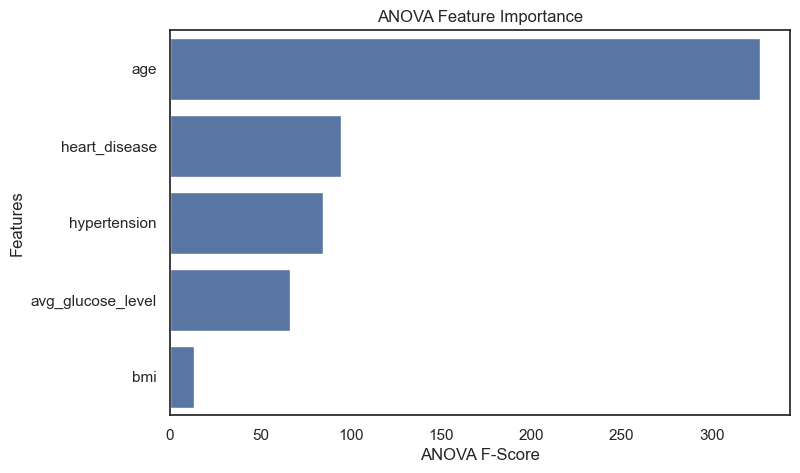

In [39]:
plt.figure(figsize=(8,5))
sns.barplot(
    x='ANOVA_Score',
    y='Feature',
    data=anova_df
)
plt.title("ANOVA Feature Importance")
plt.xlabel("ANOVA F-Score")
plt.ylabel("Features")
plt.show()


3️⃣ تطبيق RFE مع Logistic Regression

Logistic Regression مع penalty='l2' (أو L1 لو حابة feature selection أكثر حدة)

RFE يختار أفضل الـ features بناءً على الأداء الفعلي

In [40]:
# ===============================
# 2️⃣ Categorical & Numerical Features
# ===============================
categorical_features = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
numerical_features = ['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi']


In [41]:
# ===============================
# 3️⃣ ColumnTransformer + OneHotEncoding
# ===============================
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'  # numerical features remain as-is
)
# y = target
y = df['stroke']

# X = كل الأعمدة ما عدا target
x = df.drop('stroke', axis=1)

# Fit & transform the dataset
X_encoded = preprocessor.fit_transform(x)
y = df['stroke']


In [42]:
# ===============================
# 4️⃣ Get feature names correctly
# ===============================
# 4a: categorical feature names after encoding
ohe = preprocessor.named_transformers_['cat']
cat_features_encoded = ohe.get_feature_names_out(categorical_features)

# 4b: combine with numerical features
# Get all feature names including encoded categorical and passthrough numerical
feature_names = preprocessor.get_feature_names_out().tolist()

# تأكد من طولهم
print("Number of features:", X_encoded.shape[1])
print("Number of feature names:", len(feature_names))


Number of features: 14
Number of feature names: 14


In [43]:
# ===============================
# 5️⃣ Apply RFE
# ===============================
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE  # أيضًا تأكد من استيراد RFE

lr = LogisticRegression(max_iter=1000, random_state=42)
rfe = RFE(estimator=lr, n_features_to_select=8)
rfe.fit(X_encoded, y)


RFE(estimator=LogisticRegression(max_iter=1000, random_state=42),
    n_features_to_select=8)

In [44]:
# ===============================
# 6️⃣ Create DataFrame of results
# ===============================
rfe_df = pd.DataFrame({
    'Feature': feature_names,
    'Selected': rfe.support_,
    'Ranking': rfe.ranking_
}).sort_values(by='Ranking')

rfe_df

,Feature,Selected,Ranking
1,cat__ever_married_Yes,True,1
3,cat__work_type_Self-employed,True,1
7,cat__smoking_status_never smoked,True,1
4,cat__work_type_children,True,1
12,remainder__avg_glucose_level,True,1
13,remainder__bmi,True,1
10,remainder__hypertension,True,1
11,remainder__heart_disease,True,1
8,cat__smoking_status_smokes,False,2
5,cat__Residence_type_Urban,False,3


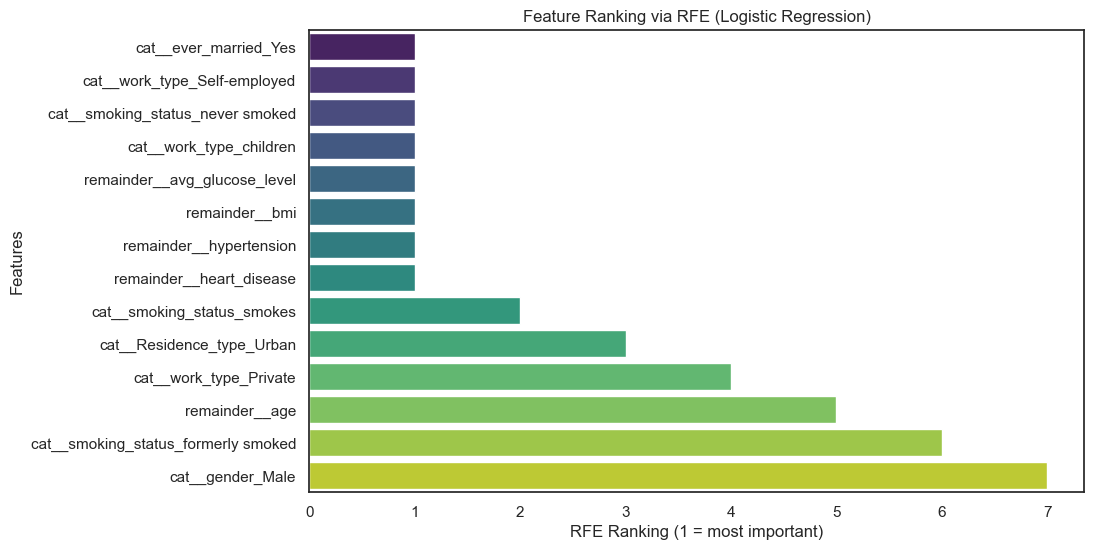

In [45]:
# ===============================
# 7️⃣ Optional Visualization
# ===============================
plt.figure(figsize=(10,6))
sns.barplot(x='Ranking', y='Feature', data=rfe_df, palette='viridis')
plt.title("Feature Ranking via RFE (Logistic Regression)")
plt.xlabel("RFE Ranking (1 = most important)")
plt.ylabel("Features")
plt.show()

#دي أفضل 8 features
cat__ever_married_Yes
cat__work_type_Self-employed
cat__smoking_status_never smoked
cat__work_type_children
remainder__avg_glucose_level
remainder__bmi
remainder__hypertension
remainder__heart_disease


#Features الأقل أهمية
cat__smoking_status_smokes
cat__Residence_type_Urban
cat__work_type_Private
remainder__age
cat__smoking_status_formerly smoked
cat__gender_Male


In [46]:
#1️⃣ Logistic Regression مع L1
from sklearn.linear_model import LogisticRegression

# Logistic Regression مع L1
lr_l1 = LogisticRegression(penalty='l1', solver='liblinear', max_iter=1000, random_state=42)

# Train the model
lr_l1.fit(X_encoded, y)

# عرض الـ coefficients
coefficients = lr_l1.coef_[0]

# إنشاء DataFrame مرتب للـ features
l1_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients,
    'Selected': coefficients != 0
}).sort_values(by='Coefficient', key=abs, ascending=False)

l1_df


,Feature,Coefficient,Selected
12,remainder__avg_glucose_level,0.419871,True
10,remainder__hypertension,0.419419,True
11,remainder__heart_disease,0.292576,True
3,cat__work_type_Self-employed,-0.259742,True
13,remainder__bmi,-0.227534,True
7,cat__smoking_status_never smoked,-0.174503,True
1,cat__ever_married_Yes,-0.173423,True
8,cat__smoking_status_smokes,0.087050,True
2,cat__work_type_Private,0.075357,True
9,remainder__age,0.071391,True


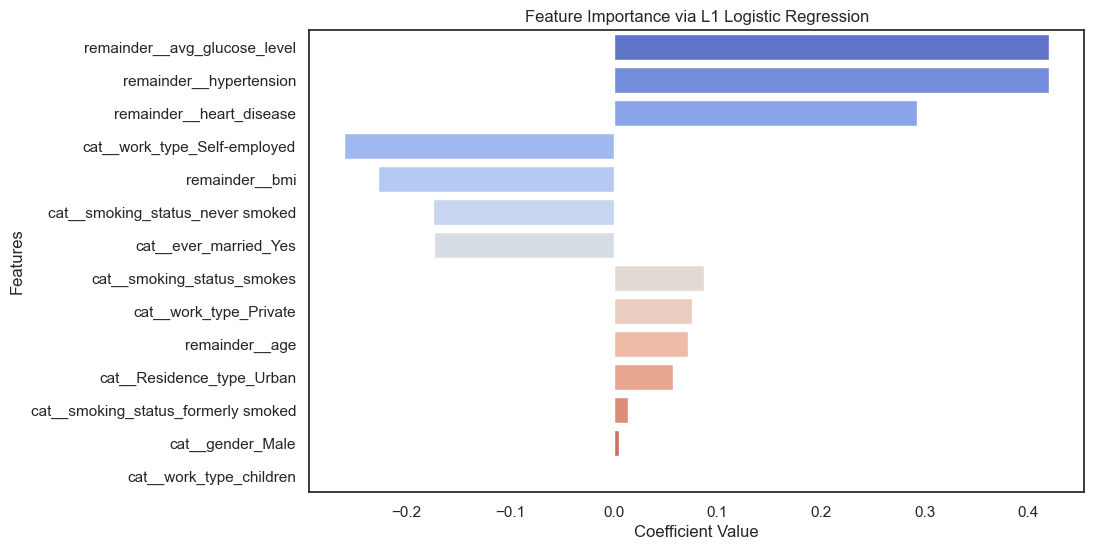

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=l1_df, palette='coolwarm')
plt.title("Feature Importance via L1 Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.show()


🔹 الاستنتاج: أفضل Features لاستخدامها في الموديل

بعد المقارنة، أفضل الخصائص التي يجب أن تكون في الموديل هي:

avg_glucose_level

hypertension

heart_disease

bmi

age

ever_married_Yes

work_type_Self-employed

smoking_status_never smoked

هذه الخصائص تظهر أهمية ثابتة عبر أكثر من طريقة → هذا يعطي ثقة أكاديمية لاستخدامهم في الموديل.

In [90]:
#2️⃣ Train/Test Split
# 80% Train, 20% Test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [91]:
#3️⃣ التعامل مع Imbalanced Data (لو موجود)
from sklearn.utils import class_weight
import numpy as np

# حساب class weights
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))
class_weights_dict


{np.int64(0): np.float64(0.5255915637860082),
 np.int64(1): np.float64(10.268844221105528)}

0 → الوزن للـ majority class (non-stroke) ≈ 0.53

1 → الوزن للـ minority class (stroke) ≈ 10.27

معنى الكلام: الموديل حيولي إعطاء أهمية أكبر جدًا للـ stroke class عشان يتعلم يصنفها بشكل صحيح رغم قلة الأمثلة.

In [52]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.utils import class_weight
import numpy as np

# ===============================
# تحديد Features و Target
# ===============================
top_features = ['avg_glucose_level', 'hypertension', 'heart_disease', 'bmi', 
                'age', 'ever_married', 'work_type', 'smoking_status']
X = df[top_features]
y = df['stroke']

# ===============================
# تحديد categorical & numerical
# ===============================
categorical_features = ['ever_married', 'work_type', 'smoking_status']
numerical_features = ['avg_glucose_level', 'hypertension', 'heart_disease', 'bmi', 'age']

# ===============================
# Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ===============================
# حساب class weights
# ===============================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

# ===============================
# Pipeline: Encoding + Scaling + Logistic Regression
# ===============================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight=class_weights_dict, random_state=42))
])

# ===============================
# تدريب الموديل
# ===============================
clf.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['avg_glucose_level',
                                                   'hypertension',
                                                   'heart_disease', 'bmi',
                                                   'age']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first'),
                                                  ['ever_married', 'work_type',
                                                   'smoking_status'])])),
                ('classifier',
                 LogisticRegression(class_weight={np.int64(0): np.float64(0.5255915637860082),
                                                  np.int64(1): np.float64(10.268844221105528)},
                                    max_iter=1000, random_state=42))])

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.utils import class_weight
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1️⃣ تحديد Features و Target
# ===============================
top_features = ['avg_glucose_level', 'hypertension', 'heart_disease', 'bmi', 
                'age', 'ever_married', 'work_type', 'smoking_status']
X = df[top_features]
y = df['stroke']

categorical_features = ['ever_married', 'work_type', 'smoking_status']
numerical_features = ['avg_glucose_level', 'hypertension', 'heart_disease', 'bmi', 'age']

# ===============================
# 2️⃣ Train/Test Split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# ===============================
# 3️⃣ حساب class weights
# ===============================
class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(zip(np.unique(y_train), class_weights))

# ===============================
# 4️⃣ Pipeline: Preprocessing + Logistic Regression
# ===============================
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])

clf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight=class_weights_dict, random_state=42))
])

# ===============================
# 5️⃣ تدريب الموديل
# ===============================
clf.fit(X_train, y_train)

# ===============================
# 6️⃣ التوقعات و Evaluation
# ===============================
y_pred = clf.predict(X_test)
y_proba = clf.predict_proba(X_test)[:,1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1-score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.7328767123287672
Precision: 0.13680781758957655
Recall: 0.84
F1-score: 0.23529411764705882
ROC-AUC: 0.8425102880658436

Confusion Matrix:
 [[707 265]
 [  8  42]]

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.73      0.84       972
           1       0.14      0.84      0.24        50

    accuracy                           0.73      1022
   macro avg       0.56      0.78      0.54      1022
weighted avg       0.95      0.73      0.81      1022



Text(0.5, 1.0, 'Confusion Matrix')

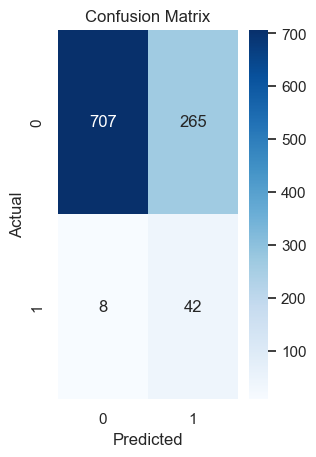

In [93]:
# ===============================
# Confusion Matrix
# ===============================
ax1 = plt.subplot(1,2,1)
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax1
)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')
ax1.set_title('Confusion Matrix')


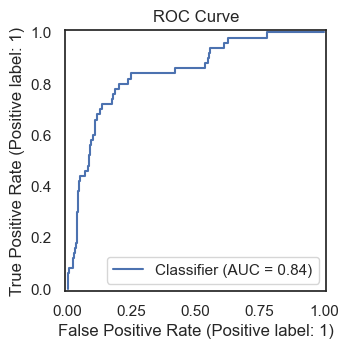

In [94]:
# ===============================
# ROC Curve
# ===============================
ax2 = plt.subplot(1,2,2)
RocCurveDisplay.from_predictions(
    y_test,
    y_proba,
    ax=ax2
)
ax2.set_title('ROC Curve')

plt.tight_layout()
plt.show()

In [95]:
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
cat_cols


['ever_married', 'work_type', 'smoking_status']

In [96]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    drop='first',
    sparse_output=False
)

encoded = encoder.fit_transform(X[cat_cols])

encoded_df = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(cat_cols),
    index=X.index
)


In [97]:
رX_encoded = pd.concat(
    [X.drop(columns=cat_cols), encoded_df],
    axis=1
)


In [98]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [99]:
#🔹 2️⃣ Decision Tree
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_proba_dt = dt.predict_proba(X_test)[:, 1]


In [100]:
dt.fit(X_train, y_train)


DecisionTreeClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [101]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1-score:", f1_score(y_test, y_pred_dt))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))


Accuracy: 0.738747553816047
Precision: 0.13220338983050847
Recall: 0.78
F1-score: 0.22608695652173913
ROC-AUC: 0.7985905349794238

Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.13      0.78      0.23        50

    accuracy                           0.74      1022
   macro avg       0.56      0.76      0.53      1022
weighted avg       0.94      0.74      0.81      1022



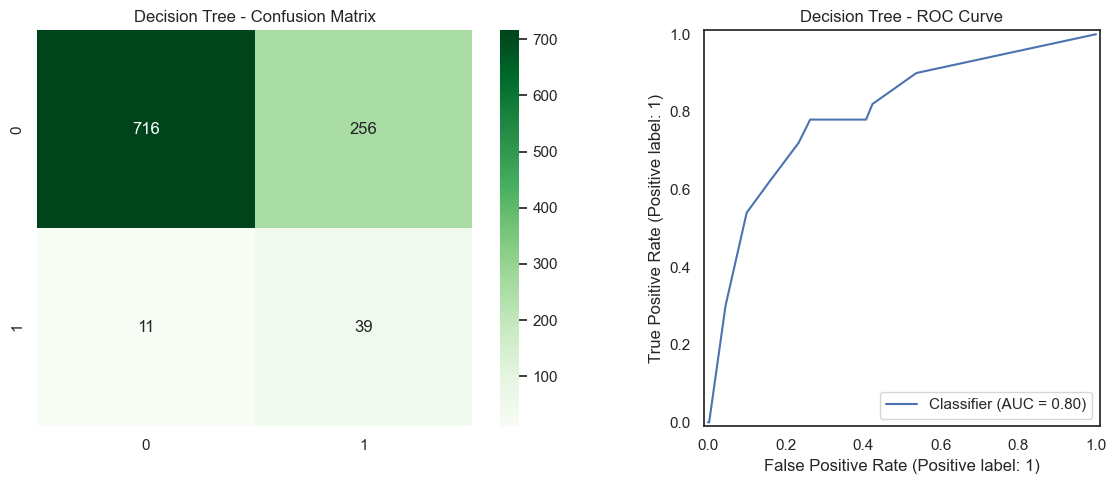

In [102]:
plt.figure(figsize=(12,5))

ax1 = plt.subplot(1,2,1)
sns.heatmap(confusion_matrix(y_test, y_pred_dt),
            annot=True, fmt='d', cmap='Greens', ax=ax1)
ax1.set_title("Decision Tree - Confusion Matrix")

ax2 = plt.subplot(1,2,2)
RocCurveDisplay.from_predictions(y_test, y_proba_dt, ax=ax2)
ax2.set_title("Decision Tree - ROC Curve")

plt.tight_layout()
plt.show()


In [ ]:
#🟢 Step 1️⃣ تدريب Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

y_proba_rf = rf.predict_proba(X_test)[:, 1]


In [ ]:
#🟢 Step 2️⃣ التنبؤ بالـ Threshold الافتراضي (0.5)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report
)

y_pred_rf_05 = (y_proba_rf >= 0.5).astype(int)

print("Threshold = 0.5")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_05))
print("Precision:", precision_score(y_test, y_pred_rf_05))
print("Recall:", recall_score(y_test, y_pred_rf_05))
print("F1-score:", f1_score(y_test, y_pred_rf_05))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, RocCurveDisplay

plt.figure(figsize=(12,5))

# Confusion Matrix
ax1 = plt.subplot(1,2,1)
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf_06),
    annot=True, fmt='d', cmap='Oranges', ax=ax1
)
ax1.set_title("Random Forest (Threshold = 0.6) - Confusion Matrix")

# ROC Curve
ax2 = plt.subplot(1,2,2)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, ax=ax2)
ax2.set_title("Random Forest - ROC Curve")

plt.tight_layout()
plt.show()


🚀 الخطوة الجاية

نقدر نعمل:
1️⃣ جدول مقارنة نهائي
2️⃣ اختيار أفضل مودل + تبرير
3️⃣ (اختياري) SMOTE + تحسين أقوى

قولي تحبي نكمل بإيه؟

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, f1_score, precision_score, recall_score

# توقع احتمالات الفئة الإيجابية
y_probs = model.predict_proba(X_test)[:,1]

# حساب Precision, Recall عند Thresholds مختلفة
precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

# رسم Precision و Recall مقابل Threshold
plt.figure(figsize=(8,6))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='red')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid()
plt.show()

# حساب F1-score عند كل Threshold
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # لتجنب القسمة على صفر
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

print(f"أفضل Threshold لتحقيق توازن Precision-Recall: {best_threshold:.3f}")

# توقع الفئة النهائية عند Threshold الأمثل
y_pred_best = (y_probs >= best_threshold).astype(int)

# تقييم الأداء عند Threshold الأمثل
print("Precision:", precision_score(y_test, y_pred_best))
print("Recall:", recall_score(y_test, y_pred_best))
print("F1-score:", f1_score(y_test, y_pred_best))


In [103]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, precision_recall_curve, auc
import matplotlib.pyplot as plt

# إنشاء الموديل
model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train, y_train)

# التوقعات
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]  # احتمالات الفئة 1


In [104]:
f1 = f1_score(y_test, y_pred)
print("F1-score:", f1)


F1-score: 0.0


Precision-Recall AUC: 0.14950913413138833


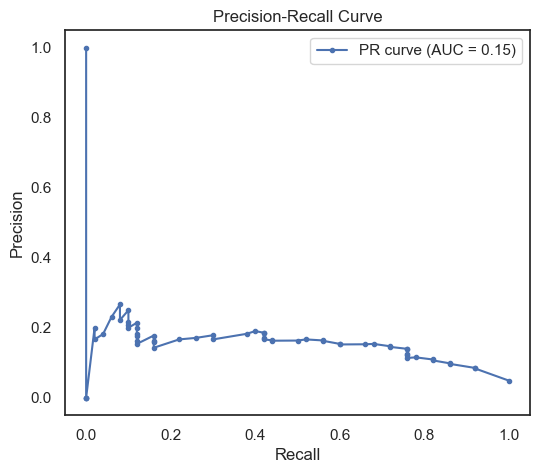

In [105]:
from sklearn.metrics import precision_recall_curve, auc

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = auc(recall, precision)

print("Precision-Recall AUC:", pr_auc)

# الرسم
plt.figure(figsize=(6,5))
plt.plot(recall, precision, marker='.', label='PR curve (AUC = %0.2f)' % pr_auc)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


In [106]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Confusion Matrix:
 [[971   1]
 [ 50   0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.97       972
           1       0.00      0.00      0.00        50

    accuracy                           0.95      1022
   macro avg       0.48      0.50      0.49      1022
weighted avg       0.90      0.95      0.93      1022

